In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn  

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.5276999999955296 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.5.20                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.17                          pyhcf101f3_0                  conda-forge                   
+ joblib                    

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# imported the data libaries above while importing my dataset below

In [6]:
df=pd.read_csv('diabetes_capstone_data.csv')

In [5]:
df.shape

(101766, 50)

# the above shows the full size of the data set. Below I am going to look at what specific values this dataset has so I can skinny it down to the columns I will be using in this research 

In [7]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [8]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [13]:
drop_cols = ['encounter_id', 'patient_nbr','admission_source_id','payer_code', 'medical_specialty','num_lab_procedures', 'num_procedures','diag_1','diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult','metformin', 'repaglinide', 'nateglinide', 'chlorpropamide','glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide','pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone','tolazamide', 'examide', 'citoglipton', 'insulin','glyburide-metformin', 'glipizide-metformin','glimepiride-pioglitazone', 'metformin-rosiglitazone','metformin-pioglitazone']

In [10]:
df.drop(drop_cols, inplace = True, axis=1)

In [11]:
df.shape

(101766, 14)

In [16]:
df=df[df["admission_type_id"].isin([1, 2, 3])]

In [17]:
df.shape

(91339, 14)

In [21]:
df= df[df['weight']!='?']

In [22]:
df.shape

(2695, 14)

In [47]:
df=df[df['race']!='?']

In [48]:
df.shape

(2589, 15)

# after a series of data clean up (removing question marks from race & weight) I will be focusing on 3 admission types that I filtered out above which ties to 1 - emergency, 2- urgent, 3- elective admission

In [49]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,time_in_hospital,num_medications,number_outpatient,number_emergency,number_inpatient,change,diabetesMed,readmitted,readmit_num
15890,Caucasian,Female,[70-80),[100-125),1,1,13,16,0,0,0,Ch,Yes,NO,0.0
15973,Caucasian,Female,[40-50),[100-125),1,2,4,12,4,0,1,Ch,Yes,<30,1.0
15992,Caucasian,Female,[80-90),[50-75),1,1,10,14,0,0,0,Ch,Yes,NO,0.0
16083,Caucasian,Female,[80-90),[50-75),2,6,9,17,0,0,0,No,No,>30,0.5
16107,Caucasian,Female,[50-60),[50-75),3,1,2,16,0,0,0,Ch,Yes,>30,0.5


# I first want to look at the data by race and sex to see how the admissions data was broken out 

In [50]:
race_gender = df.groupby(["race", "gender"]).size().unstack()

<function matplotlib.pyplot.show(close=None, block=None)>

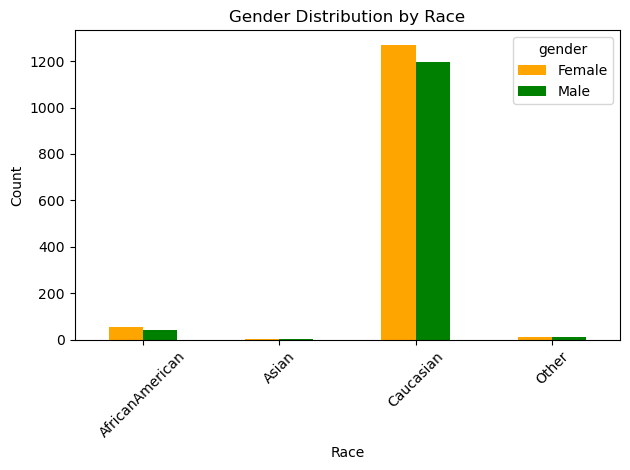

In [85]:
race_gender.plot(kind="bar", color=["orange", "green"])
plt.title("Gender Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

# Used some additonal codes to see if the length of stay impacted the readmission numbers 

In [28]:
df["readmit_num"] = df["readmitted"].map({"<30": 1, ">30" :0.5, "NO" : 0})

In [29]:
df["time_in_hospital"].corr(df["readmit_num"])

np.float64(0.02639451557926648)

Text(0, 0.5, 'Length of Stay')

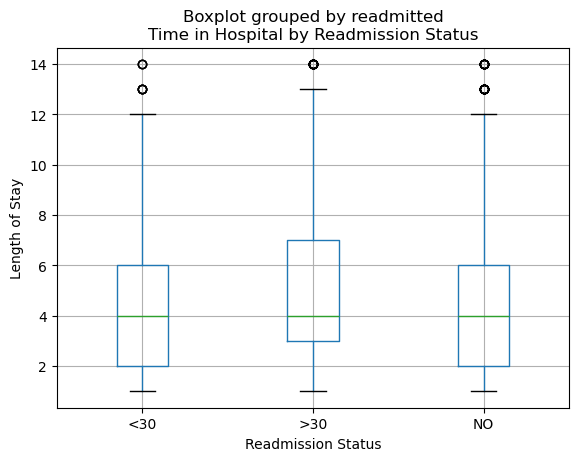

In [30]:
df.boxplot(column="time_in_hospital", by="readmitted")
plt.title("Time in Hospital by Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Length of Stay")

In [31]:
df["admission_type_id"] = df["admission_type_id"].astype(int)

In [32]:
correlation = df["admission_type_id"].corr(df["readmit_num"])

In [33]:
print("Correlation between admission type and readmission:", correlation)

Correlation between admission type and readmission: -0.0016151073104308262


# I used the above to try to see the correlation between the type of admission and if that impacted the admission but the data wasnt very helpful so the below shows the readmission breakdown for admission type 1 = emergent 

In [34]:
df_emergency = df[df["admission_type_id"] == 1]

In [35]:
readmit_counts = df_emergency["readmitted"].value_counts()

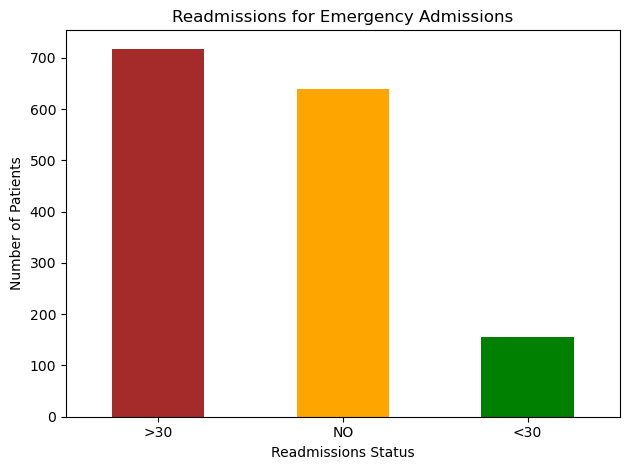

In [86]:
readmit_counts.plot(kind="bar", color=["brown", "orange", "green"])
plt.title("Readmissions for Emergency Admissions")
plt.xlabel("Readmissions Status")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# After doing this code I realized it would make more sense to view the 3 types of admissions and their readmission values all in one table 

In [37]:
table = df.groupby(["admission_type_id", "readmitted"]).size().unstack()

In [38]:
table_pct = table.div(table.sum(axis=1), axis=0) * 100

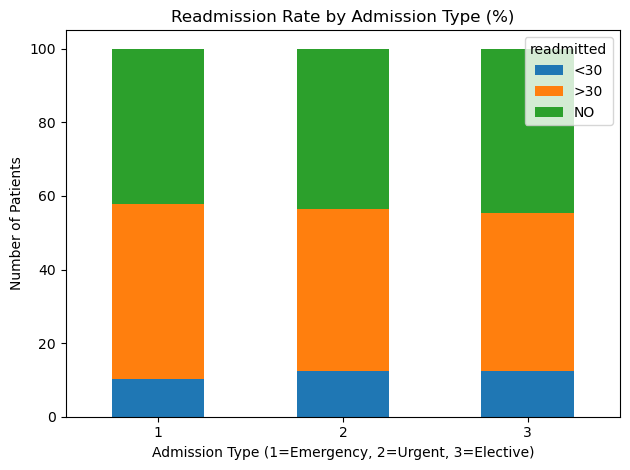

In [39]:
table_pct.plot(kind="bar", stacked=True)
plt.title("Readmission Rate by Admission Type (%)")
plt.xlabel("Admission Type (1=Emergency, 2=Urgent, 3=Elective)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# I then wanted to see if there was some relationship between the number of medications the patients are taking and the rate of readmission 

Text(0, 0.5, 'Number of Medications')

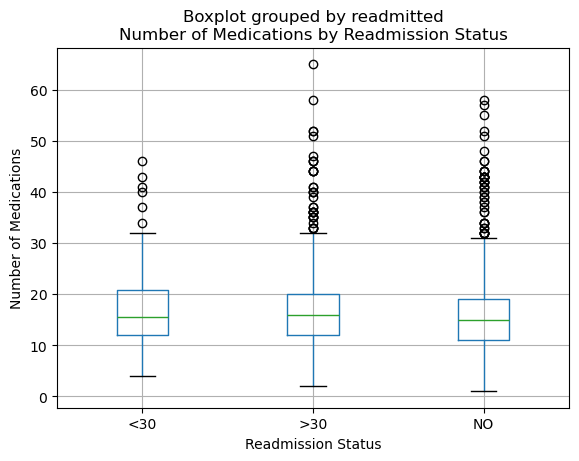

In [87]:
df.boxplot(column="num_medications", by="readmitted")
plt.title("Number of Medications by Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Medications")

# Afterwards I was also curious to see if the number of medication impacted the length of stay since I did see from the above that it did impact the rate of readmission 

In [42]:
avg_los = df.groupby("diabetesMed")["time_in_hospital"].mean()

<function matplotlib.pyplot.show(close=None, block=None)>

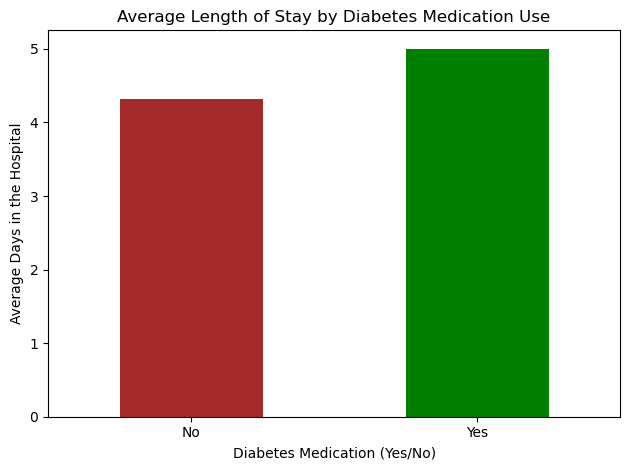

In [88]:
avg_los.plot(kind="bar", color=["brown", "green"])
plt.title("Average Length of Stay by Diabetes Medication Use")
plt.xlabel("Diabetes Medication (Yes/No)")
plt.ylabel("Average Days in the Hospital")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show

# Looking at differences in average hospital length of stay across racial groups 

In [53]:
avg_los_race = df.groupby("race")["time_in_hospital"].mean()

<function matplotlib.pyplot.show(close=None, block=None)>

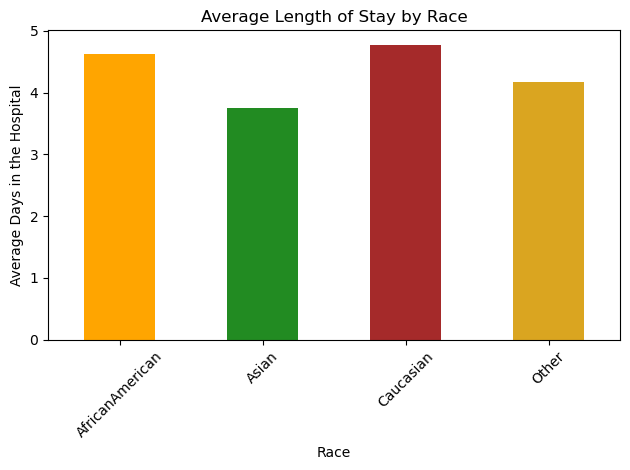

In [92]:
avg_los_race.plot(kind="bar", color=["orange", "forestgreen", "brown", "goldenrod"])
plt.title("Average Length of Stay by Race")
plt.xlabel("Race")
plt.ylabel("Average Days in the Hospital")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

# Looking at length of stay by age group 

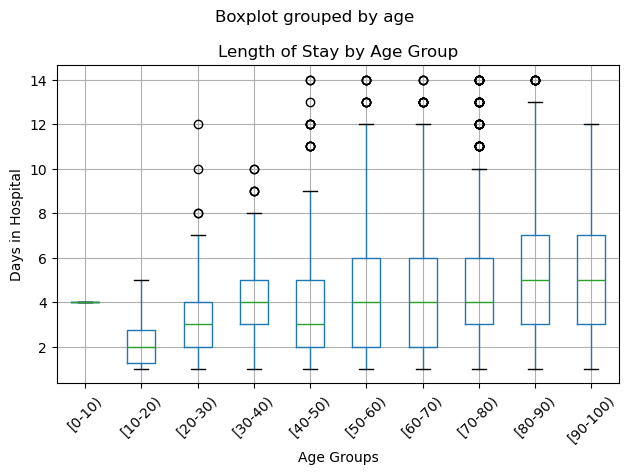

In [63]:
df.boxplot(column="time_in_hospital", by="age")
plt.title("Length of Stay by Age Group")
plt.xlabel("Age Groups")
plt.ylabel("Days in Hospital")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# looking at the length of stay amongst different sexes 

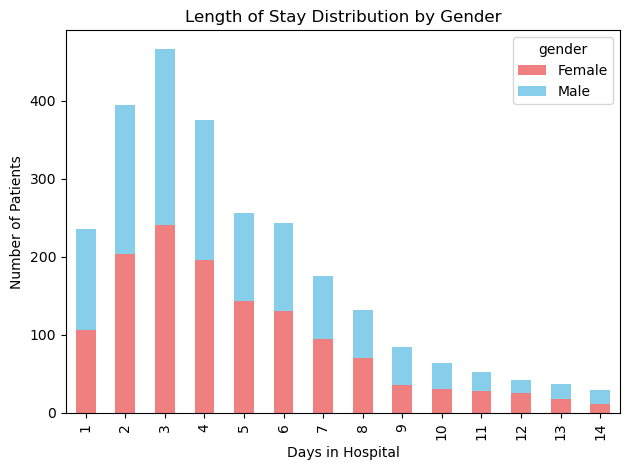

In [79]:
df.groupby("gender")["time_in_hospital"].value_counts().unstack().T.plot(kind="bar", stacked=True, color=["lightcoral", "skyblue"])
plt.title("Length of Stay Distribution by Gender")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

# In conclusion, lenght of stay varies based on whether the patient was on diabetes medication, race, age, and slight variation in gender. We also saw a trend between length of stay and readmission rates 10